**Analisis Tren Ekonomi Digital ASEAN Menggunakan Data Historis 2019-2023**

Kelompok 9 2024D:
1. Nia Ayu Agustin (24031554081)
2. Aulia Aziza (24031554102)
3. Audy Alycia (24031554179)

In [ ]:
import os
import subprocess

java_home = r"C:\Program Files\Eclipse Adoptium\jdk-21.0.11.10-hotspot" #path instalasi jdk 21
os.environ["JAVA_HOME"] = java_home
os.environ["PATH"] = java_home + r"\bin;" + os.environ.get("PATH", "") #variabel java home agar atoti dapat menemukan java

result = subprocess.run(["java", "-version"], capture_output=True, text=True)
print(result.stderr)
print("JAVA_HOME:", os.environ["JAVA_HOME"])

openjdk version "21.0.11" 2026-04-21 LTS
OpenJDK Runtime Environment Temurin-21.0.11+10 (build 21.0.11+10-LTS)
OpenJDK 64-Bit Server VM Temurin-21.0.11+10 (build 21.0.11+10-LTS, mixed mode, sharing)

JAVA_HOME: C:\Program Files\Eclipse Adoptium\jdk-21.0.11.10-hotspot


In [ ]:
import atoti as tt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, json, time, os
from datetime import datetime
from sqlalchemy import create_engine, text #untuk koneksi ke database
from urllib.parse import quote_plus #encode karakter khusus pada string koneksi database
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
print("Setup selesai")

Welcome to Atoti 0.9.15!

By using this community edition, you agree with the license available at https://docs.activeviam.com/products/atoti/python-sdk/latest/eula.html.
Browse the official documentation at https://docs.activeviam.com/products/atoti/python-sdk.
Join the community at https://www.atoti.io/register.

Atoti collects telemetry data, which is used to help understand how to improve the product.
If you don't wish to send usage data, you can request a trial license at https://www.atoti.io/evaluation-license-request.

You can hide this message by setting the `ATOTI_HIDE_EULA_MESSAGE` environment variable to True.
Setup selesai


# Load Data

Dataset bersumber dari UNCTADstat (World Bank Data360) dalam format wide, di mana setiap baris mewakili satu kombinasi negara dan indikator, sedangkan nilai per tahun tersebar ke kolom masing-masing. Proses ekstraksi berhasil membaca 1.042 baris dengan 32 kolom, mencakup 204 negara/wilayah dan 14 indikator yang semuanya berfrekuensi tahunan. Rentang data yang tersedia adalah 2010–2023 (14 tahun), namun analisis difokuskan pada periode 2019–2023 (5 tahun) karena periode tersebut paling relevan dengan kondisi perdagangan jasa digital pasca pandemi.

In [3]:
CSV_PATH = "UNCTAD_DE_WIDEF.csv"

In [4]:
ASEAN_CODES = {
    'BRN': 'Brunei Darussalam',
    'KHM': 'Cambodia',
    'IDN': 'Indonesia',
    'LAO': 'Lao PDR',
    'MYS': 'Malaysia',
    'MMR': 'Myanmar',
    'PHL': 'Philippines',
    'SGP': 'Singapore',
    'THA': 'Thailand',
    'VNM': 'Viet Nam'
} #code ISO untuk 10 negara ASEAN

In [5]:
TRADE_INDICATORS = [
    'UNCTAD_DE_DIG_SERVTRADE_ANN_EXP',
    'UNCTAD_DE_DIG_SERVTRADE_ANN_IMP'
] #digunakan untuk ekspor & impor jasa digital

In [ ]:
YEAR_COLS_ALL = [str(y) for y in range(2010, 2024)]
YEAR_COLS_FOCUS = [str(y) for y in range(2019, 2024)] #fokus analisis pada 5 tahun terakhir (2019-2023) untuk melihat tren terbaru

In [7]:
print(f"Periode raw: 2010–2023 ({len(YEAR_COLS_ALL)} tahun)")
print(f"Periode target: 2019–2023 ({len(YEAR_COLS_FOCUS)} tahun)")
print(f"Negara ASEAN: {list(ASEAN_CODES.keys())}")

Periode raw: 2010–2023 (14 tahun)
Periode target: 2019–2023 (5 tahun)
Negara ASEAN: ['BRN', 'KHM', 'IDN', 'LAO', 'MYS', 'MMR', 'PHL', 'SGP', 'THA', 'VNM']


In [8]:
df_raw = pd.read_csv(CSV_PATH)

In [ ]:
staging_log = {
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'), #waktu ekstraksi
    'source': 'UNCTAD_DE_WIDEF.csv (World Bank Data360 / UNCTADstat)',
    'total_rows': df_raw.shape[0], #jumlah baris dataset mentah
    'total_cols': df_raw.shape[1], #jumlah kolom dataset mentah
    'negara_unik': df_raw['REF_AREA'].nunique(), #jumlah negara unik dalam dataset
    'indikator_unik': df_raw['INDICATOR'].nunique(), #jumlah indikator unik dalam dataset
    'status': 'SUCCESS'
} #catat metadata ekstraksi sebagai audit trail

for k, v in staging_log.items():
    print(f"{k:<20}: {v}")

print(f"\nKolom: {df_raw.columns.tolist()}")
df_raw.head(3)

timestamp           : 2026-06-06 21:13:48
source              : UNCTAD_DE_WIDEF.csv (World Bank Data360 / UNCTADstat)
total_rows          : 1042
total_cols          : 32
negara_unik         : 204
indikator_unik      : 14
status              : SUCCESS

Kolom: ['FREQ', 'FREQ_LABEL', 'REF_AREA', 'REF_AREA_LABEL', 'INDICATOR', 'INDICATOR_LABEL', 'UNIT_MEASURE', 'UNIT_MEASURE_LABEL', 'AGG_METHOD', 'AGG_METHOD_LABEL', 'DATABASE_ID', 'DATABASE_ID_LABEL', 'UNIT_MULT', 'UNIT_MULT_LABEL', 'OBS_STATUS', 'OBS_STATUS_LABEL', 'OBS_CONF', 'OBS_CONF_LABEL', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']


,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,UNIT_MEASURE,UNIT_MEASURE_LABEL,AGG_METHOD,AGG_METHOD_LABEL,DATABASE_ID,DATABASE_ID_LABEL,UNIT_MULT,UNIT_MULT_LABEL,OBS_STATUS,OBS_STATUS_LABEL,OBS_CONF,OBS_CONF_LABEL,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,A,Annual,ABW,Aruba,UNCTAD_DE_DIG_SERVTRADE_ANN_EXP,International exports in digitally-deliverable...,USD,US dollars,SUM,Sum,UNCTAD_DE,Digital Economy and Technology,6,Millions,A,Normal value,PU,Public,83.00,96.00,104.00,73.00,75.00,82.00,83.00,72.00,84.00,95.00,125.00,119.00,126.00,137.00
1,A,Annual,ABW,Aruba,UNCTAD_DE_DIG_SERVTRADE_ANN_IMP,International imports in digitally-deliverable...,USD,US dollars,SUM,Sum,UNCTAD_DE,Digital Economy and Technology,6,Millions,A,Normal value,PU,Public,270.00,291.00,336.00,353.00,411.00,375.00,404.00,405.00,435.00,427.00,359.00,442.00,489.00,525.00
2,A,Annual,AFG,Afghanistan,UNCTAD_DE_DIG_SERVTRADE_ANN_EXP,International exports in digitally-deliverable...,USD,US dollars,SUM,Sum,UNCTAD_DE,Digital Economy and Technology,6,Millions,A,Normal value,PU,Public,818.00,"1,066.00",638.00,296.00,456.00,311.00,176.00,170.00,249.00,214.00,375.00,NaN,NaN,NaN


# EDA

Data Mentah

In [10]:
#statistik
print(f"Total baris: {df_raw.shape[0]:,}")
print(f"Total kolom: {df_raw.shape[1]}")
print(f"Negara/wilayah unik: {df_raw['REF_AREA'].nunique()}")
print(f"Indikator unik: {df_raw['INDICATOR'].nunique()}")
print(f"Frekuensi: {df_raw['FREQ_LABEL'].unique()}")

Total baris: 1,042
Total kolom: 32
Negara/wilayah unik: 204
Indikator unik: 14
Frekuensi: ['Annual']


Dataset berhasil diekstrak dari sumber UNCTADstat dengan total 1.042 baris, 32 kolom, mencakup 204 negara dan 14 indikator unik. Seluruh data berfrekuensi tahunan dan proses ekstraksi berjalan tanpa error.

In [ ]:
#daftar indikator
print("Daftar Indikator:")
for ind, cnt in df_raw['INDICATOR'].value_counts().items():
    label = df_raw[df_raw['INDICATOR'] == ind]['INDICATOR_LABEL'].iloc[0][:55] #ambil label indikator untuk koneksi, dipotong 55 karakter agar rapi
    unit = df_raw[df_raw['INDICATOR'] == ind]['UNIT_MEASURE_LABEL'].iloc[0] #ambil satuan ukuran indikator
    print(f"[{cnt:>4} baris] {ind} | {unit}")

Daftar Indikator:
[ 203 baris] UNCTAD_DE_DIG_SERVTRADE_ANN_IMP | US dollars
[ 200 baris] UNCTAD_DE_DIG_SERVTRADE_ANN_EXP | US dollars
[  69 baris] UNCTAD_DE_ICT_CORE_UBS_ANN_ALL_B3 | Percentage of businesses
[  67 baris] UNCTAD_DE_ICT_CORE_UISIC4_ANN_00_B5 | Percentage of businesses
[  65 baris] UNCTAD_DE_ICT_CORE_UBS_ANN_ALL_B1 | Percentage of businesses
[  64 baris] UNCTAD_DE_ICT_CORE_UISIC3N1_ANN_00_B7 | Percentage of businesses
[  64 baris] UNCTAD_DE_ICT_CORE_UISIC4_ANN_00_B8 | Percentage of businesses
[  55 baris] UNCTAD_DE_ICT_CORE_UISIC4_ANN_00_B4 | Percentage of employees
[  54 baris] UNCTAD_DE_ICT_CORE_UBS_ANN_ALL_B2 | Percentage of employees
[  54 baris] UNCTAD_DE_ICT_CORE_UISIC3N1_ANN_00_B6 | Percentage of businesses
[  52 baris] UNCTAD_DE_ICT_CORE_UBS_ANN_ALL_B10 | Percentage of businesses
[  49 baris] UNCTAD_DE_ICT_CORE_UISIC4_ANN_00_B11 | Percentage of businesses
[  23 baris] UNCTAD_DE_ICT_CORE_UBS_ANN_ALL_B12_IDEL | Percentage of businesses
[  23 baris] UNCTAD_DE_ICT_COR

In [ ]:
#sparsity global, berapa persen sel kosong
total_cells = df_raw.shape[0] * len(YEAR_COLS_ALL)
miss_cells = df_raw[YEAR_COLS_ALL].isnull().sum().sum() #totall sel kosong
sparsity_pct = miss_cells / total_cells * 100 #presentase sel kosong

print(f"Kombinasi (baris × {len(YEAR_COLS_ALL)} tahun): {total_cells:,}")
print(f"Sel kosong: {miss_cells:,}")
print(f"Global sparsity: {sparsity_pct:.1f}%")

Kombinasi (baris × 14 tahun): 14,588
Sel kosong: 6,897
Global sparsity: 47.3%


In [ ]:
#sparsity per indikator
print("Sparsity per Indikator")
for ind, grp in df_raw.groupby('INDICATOR'):
    tot = grp.shape[0] * len(YEAR_COLS_ALL)
    mis = grp[YEAR_COLS_ALL].isnull().sum().sum()
    cat = 'ICT' if 'ICT' in ind else 'TRADE' #kategori indikator ICT atau TRADE
    print(f"[{cat}] {ind[-30:]:<32} = {mis/tot*100:.1f}% missing")

Sparsity per Indikator
[TRADE] NCTAD_DE_DIG_SERVTRADE_ANN_EXP   = 6.8% missing
[TRADE] NCTAD_DE_DIG_SERVTRADE_ANN_IMP   = 6.9% missing
[ICT] TAD_DE_ICT_CORE_UBS_ANN_ALL_B1   = 66.5% missing
[ICT] AD_DE_ICT_CORE_UBS_ANN_ALL_B10   = 87.0% missing
[ICT] _ICT_CORE_UBS_ANN_ALL_B12_IDEL   = 81.4% missing
[ICT] TAD_DE_ICT_CORE_UBS_ANN_ALL_B2   = 70.0% missing
[ICT] TAD_DE_ICT_CORE_UBS_ANN_ALL_B3   = 67.1% missing
[ICT] DE_ICT_CORE_UISIC3N1_ANN_00_B6   = 85.7% missing
[ICT] DE_ICT_CORE_UISIC3N1_ANN_00_B7   = 65.6% missing
[ICT] _DE_ICT_CORE_UISIC4_ANN_00_B11   = 87.2% missing
[ICT] T_CORE_UISIC4_ANN_00_B12_ICUST   = 80.1% missing
[ICT] D_DE_ICT_CORE_UISIC4_ANN_00_B4   = 66.1% missing
[ICT] D_DE_ICT_CORE_UISIC4_ANN_00_B5   = 66.5% missing
[ICT] D_DE_ICT_CORE_UISIC4_ANN_00_B8   = 68.0% missing


Dari 14.588 kombinasi sel, hampir separuhnya kosong dengan global sparsity 47,3%. Namun angka ini didominasi oleh indikator ICT yang missingnya mencapai 65–87%. Dua indikator perdagangan yang menjadi fokus justru sangat lengkap, hanya 6,8–6,9% missing, sehingga layak digunakan untuk analisis.

# EDA ASEAN

In [ ]:
df_asean_all = df_raw[df_raw['REF_AREA'].isin(ASEAN_CODES.keys())].copy() #filter hanya 10 negara asean berdasarkan kode ISO

In [15]:
print("Data ASEAN di Dataset (sebelum filter ICT)")
print(f"Total baris ASEAN: {df_asean_all.shape[0]}")
print(f"Indikator yang ada:")
print(df_asean_all['INDICATOR'].value_counts().to_string())

Data ASEAN di Dataset (sebelum filter ICT)
Total baris ASEAN: 79
Indikator yang ada:
INDICATOR
UNCTAD_DE_DIG_SERVTRADE_ANN_EXP               10
UNCTAD_DE_DIG_SERVTRADE_ANN_IMP               10
UNCTAD_DE_ICT_CORE_UBS_ANN_ALL_B3              7
UNCTAD_DE_ICT_CORE_UISIC4_ANN_00_B5            7
UNCTAD_DE_ICT_CORE_UBS_ANN_ALL_B1              6
UNCTAD_DE_ICT_CORE_UISIC3N1_ANN_00_B7          5
UNCTAD_DE_ICT_CORE_UISIC4_ANN_00_B8            5
UNCTAD_DE_ICT_CORE_UBS_ANN_ALL_B10             5
UNCTAD_DE_ICT_CORE_UBS_ANN_ALL_B12_IDEL        5
UNCTAD_DE_ICT_CORE_UISIC3N1_ANN_00_B6          5
UNCTAD_DE_ICT_CORE_UISIC4_ANN_00_B12_ICUST     4
UNCTAD_DE_ICT_CORE_UISIC4_ANN_00_B11           4
UNCTAD_DE_ICT_CORE_UBS_ANN_ALL_B2              3
UNCTAD_DE_ICT_CORE_UISIC4_ANN_00_B4            3


In [ ]:
print("Berapa negara ASEAN punya data ICT pada Rentang 2019-2023")
ict_df = df_asean_all[df_asean_all['INDICATOR'].str.contains('ICT')] #filterbaris dengan indikator ICT
negara_dengan_ict = set()
for _, row in ict_df.iterrows():
    vals = row[YEAR_COLS_FOCUS].dropna() #ambil tahun 2019-2023, buang missing value
    if len(vals) > 0:
        negara_dengan_ict.add(row['REF_AREA_LABEL']) #tambahkan  egara yang setidaknya punya satu data

print(f"Negara dengan ≥1 data ICT: {len(negara_dengan_ict)} dari 10")
print(f"Negara dengan dat ICT: {negara_dengan_ict}")

Berapa negara ASEAN punya data ICT pada Rentang 2019-2023
Negara dengan ≥1 data ICT: 4 dari 10
Negara dengan dat ICT: {'Philippines', 'Thailand', 'Malaysia', 'Indonesia'}


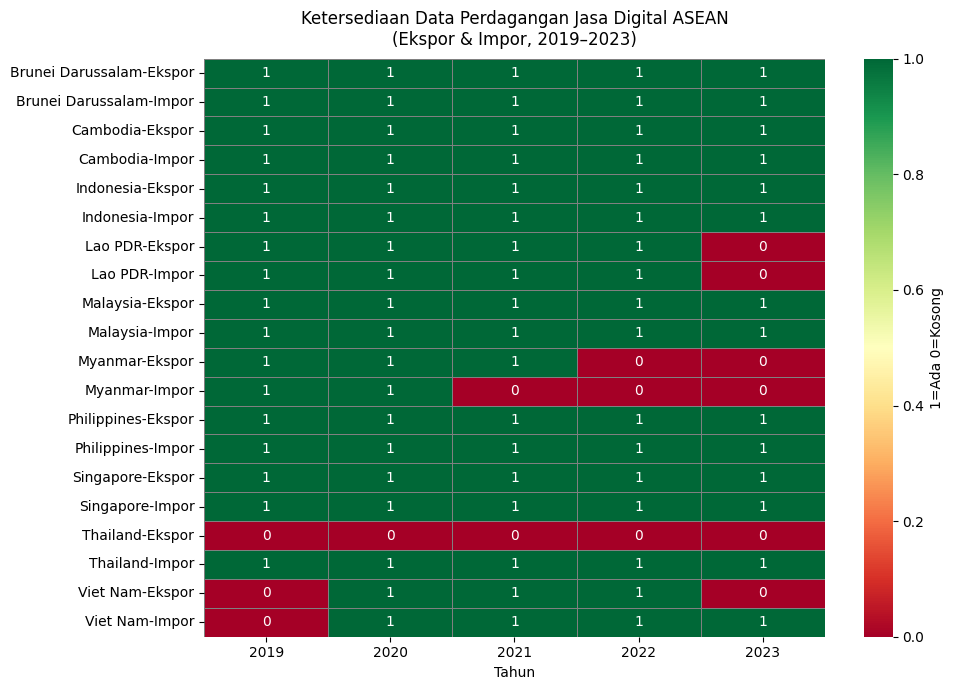

In [ ]:
trade_asean = df_asean_all[df_asean_all['INDICATOR'].isin(TRADE_INDICATORS)].copy() #filter hanya trade untuk heatmap

rows_heat = []
for _, row in trade_asean.iterrows():
    for yr in YEAR_COLS_FOCUS:
        rows_heat.append({
            'negara': row['REF_AREA_LABEL'],
            'indikator': 'Ekspor' if 'EXP' in row['INDICATOR'] else 'Impor', #tipe transaksi
            'tahun': int(yr),
            'ada': 0 if pd.isnull(row[yr]) else 1, #1 ada data, 0 berarti kosong
            'nilai': row[yr]
        })
df_heat = pd.DataFrame(rows_heat) #tabel biner ada atau tidaknya data per negara per tahun

pivot_h = df_heat.pivot_table( index=['negara', 'indikator'], columns='tahun', values='ada', aggfunc='max').fillna(0)

#heatmap ketersediaan data
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot_h, cmap='RdYlGn', linewidths=0.5, linecolor='gray', vmin=0, vmax=1, cbar_kws={'label': '1=Ada 0=Kosong'}, annot=True, fmt='.0f', ax=ax)
ax.set_title('Ketersediaan Data Perdagangan Jasa Digital ASEAN\n' '(Ekspor & Impor, 2019–2023)', fontsize=12, pad=10)
ax.set_xlabel('Tahun'); ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
#sparsity data di asean
print("Sparsity Subset ASEAN 2019-2023")
total_ideal = 10 * 2 * 5 #10 negara x 2 indikator x 5 tahun
data_ada = df_heat[df_heat['ada'] == 1].shape[0] #berapa yang benar benar ada
data_kosong = total_ideal - data_ada
sparse_asean = data_kosong / total_ideal * 100 #presentase yang kosong
print(f"Kombinasi ideal (10×2×5): {total_ideal}")
print(f"Data tersedia: {data_ada}")
print(f"Data kosong: {data_kosong}")
print(f"Sparsity subset ASEAN: {sparse_asean:.1f}%")

Sparsity Subset ASEAN 2019-2023
Kombinasi ideal (10×2×5): 100
Data tersedia: 85
Data kosong: 15
Sparsity subset ASEAN: 15.0%


In [ ]:
print("Kelengkapan per negara:")
kelengkapan = df_heat.groupby('negara')['ada'].agg(['sum', 'count']) #hitung ada dan total kombinasi per negara
kelengkapan['persen'] = kelengkapan['sum'] / kelengkapan['count'] * 100 #presentase kelengkapan
kelengkapan.columns = ['Ada', 'Total', '%Lengkap']
kelengkapan = kelengkapan.sort_values('%Lengkap', ascending=False)
print(kelengkapan.to_string())

Kelengkapan per negara:
                   Ada  Total  %Lengkap
negara                                 
Brunei Darussalam   10     10    100.00
Cambodia            10     10    100.00
Indonesia           10     10    100.00
Malaysia            10     10    100.00
Singapore           10     10    100.00
Philippines         10     10    100.00
Lao PDR              8     10     80.00
Viet Nam             7     10     70.00
Myanmar              5     10     50.00
Thailand             5     10     50.00


Dari 10 negara ASEAN, hanya 4 yang memiliki data ICT pada 2019–2023 yaitu Philippines, Thailand, Malaysia, dan Indonesia. Keterbatasan cakupan ini memperkuat keputusan untuk mengecualikan indikator ICT dari analisis, dan memfokuskan seluruh pipeline pada data perdagangan jasa digital saja. Heatmap menunjukkan 6 negara dengan kelengkapan data 100% yaitu Brunei Darussalam, Cambodia, Indonesia, Malaysia, Philippines, dan Singapore. Thailand sama sekali tidak memiliki data ekspor di seluruh periode (baris ekspor merah penuh), sedangkan Myanmar kehilangan data ekspor sejak 2022. Lao PDR dan Viet Nam masing-masing kehilangan beberapa titik data di tahun tertentu. Secara keseluruhan sparsity subset ASEAN hanya 15%, jauh lebih baik dari sparsity global 47,3%.

# Singapore Effect

In [20]:
rows_eda = []
for _, row in trade_asean.iterrows():
    tipe = 'Ekspor' if 'EXP' in row['INDICATOR'] else 'Impor'
    for yr in YEAR_COLS_FOCUS:
        if not pd.isnull(row[yr]): #hanya ambil baris yang ada nilainya
            rows_eda.append({
                'negara': row['REF_AREA_LABEL'],
                'kode': row['REF_AREA'],
                'tipe': tipe,
                'tahun': int(yr),
                'nilai': row[yr]
            })
df_eda = pd.DataFrame(rows_eda)

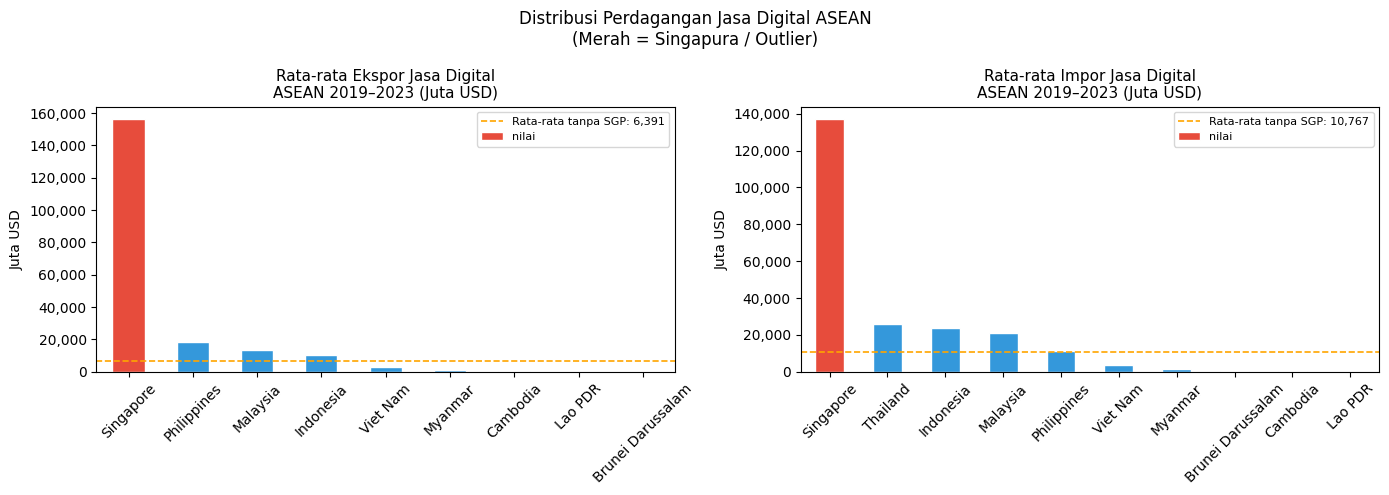

In [ ]:
#plot bar rata-rata per negara, singapura sebagai outlier
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, tipe in zip(axes, ['Ekspor', 'Impor']):
    sub = df_eda[df_eda['tipe'] == tipe]
    mean_neg = sub.groupby('negara')['nilai'].mean().sort_values(ascending=False) #rata-rataper negara
    colors = ['#e74c3c' if c == 'Singapore' else '#3498db' for c in mean_neg.index]
    mean_neg.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
    ax.set_title(f'Rata-rata {tipe} Jasa Digital\nASEAN 2019–2023 (Juta USD)', fontsize=11)
    ax.set_ylabel('Juta USD')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    avg_ex_sgp = sub[sub['negara'] != 'Singapore']['nilai'].mean() #rata-rata tanpa singapura
    ax.axhline(avg_ex_sgp, color='orange', linestyle='--', linewidth=1.2, label=f'Rata-rata tanpa SGP: {avg_ex_sgp:,.0f}')
    ax.legend(fontsize=8)

fig.suptitle('Distribusi Perdagangan Jasa Digital ASEAN\n(Merah = Singapura / Outlier)', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
print("Rasio Singapura vs Rata-rata Negara Lain")
for tipe in ['Ekspor', 'Impor']:
    sub = df_eda[df_eda['tipe'] == tipe]
    sgp = sub[sub['kode'] == 'SGP']['nilai'].mean() #rata-rata singapura
    others = sub[sub['kode'] != 'SGP']['nilai'].mean() #rata-rata negara lain
    if not np.isnan(sgp):
        print(f"{tipe}: SGP={sgp:>12,.1f} lainnya={others:>10,.1f} " f"rasio={sgp/others:.0f}× lebih tinggi")

Rasio Singapura vs Rata-rata Negara Lain
Ekspor: SGP=   156,221.8 lainnya=   6,390.7 rasio=24× lebih tinggi
Impor: SGP=   137,033.6 lainnya=  10,766.9 rasio=13× lebih tinggi


Singapura terbukti menjadi outlier ekstrem di kawasan ASEAN. Rata-rata ekspor Singapura mencapai 156.221,8 juta USD, atau 24 kali lebih tinggi dari rata-rata negara ASEAN lainnya sebesar 6.390,7 juta USD. Pola serupa terjadi pada impor, di mana Singapura mencatat rata-rata 137.033,6 juta USD atau 13 kali lebih tinggi dari rata-rata negara lain sebesar 10.766,9 juta USD. Kesenjangan ini terlihat sangat mencolok pada bar chart, di mana batang Singapura jauh melampaui garis rata-rata, sementara seluruh negara lain berada di bawahnya. Keberadaan Singapura sebagai pusat keuangan dan teknologi regional menjadikannya tidak representatif jika digabung langsung dalam perbandingan antar negara, sehingga perlu diperhatikan dalam interpretasi analisis kawasan.


# Cleaning

Tahap cleaning dimulai dengan mengidentifikasi kolom-kolom yang nilainya konstan atau tidak informatif sepanjang seluruh baris, lalu menghapusnya agar tidak menambah dimensi yang tidak berguna. Selanjutnya baris duplikat dihapus, dan seluruh representasi nilai kosong, maupun string kosong distandarisasi menjadi NaN agar konsisten dalam penanganan missing value di tahap berikutnya.

In [ ]:
konstan_cols = [c for c in df_raw.columns if df_raw[c].nunique(dropna=False) <= 1 and c not in YEAR_COLS_ALL] #kolom yang isinya konstan/tidak informatif utuk dihapus, kecuali kolom tahun
print(f"Kolom konstan/dummy ditemukan: {konstan_cols}")

df_clean = df_raw.copy() #salin dataset mentah untuk dibersihkan tanpa merubah data asli

Kolom konstan/dummy ditemukan: ['FREQ', 'FREQ_LABEL', 'DATABASE_ID', 'DATABASE_ID_LABEL', 'OBS_STATUS', 'OBS_STATUS_LABEL', 'OBS_CONF', 'OBS_CONF_LABEL']


In [24]:
df_clean = df_clean.drop(columns=konstan_cols, errors='ignore') #hapus kolom konstan

In [ ]:
n_before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates() #hapus baris yang duplikat
print(f"Duplikat dihapus: {n_before - df_clean.shape[0]} baris")

Duplikat dihapus: 0 baris


In [26]:
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].replace( ['Not Available', 'NA', 'N/A', '', ' '], np.nan) #ganti null menjadi nan

print(f"Shape setelah cleansing: {df_clean.shape}")

Shape setelah cleansing: (1042, 24)


# Standarisasi

Format teks pada kolom kode negara, nama negara, dan kode indikator diseragamkan dengan menghapus spasi berlebih dan memastikan konsistensi huruf kapital. Seluruh kolom tahun dikonversi ke tipe numerik agar bisa dihitung dan difilter, nilai yang tidak bisa dikonversi otomatis menjadi NaN. Kolom AGG_METHOD yang kosong diisi dengan nilai default 'SUM' sesuai dengan metode agregasi yang berlaku untuk indikator perdagangan ini.

In [ ]:
df_clean['REF_AREA'] = df_clean['REF_AREA'].str.strip().str.upper() #hilangkan spasi dan 
df_clean['REF_AREA_LABEL'] = df_clean['REF_AREA_LABEL'].str.strip() #hilangkan spasi nama negara
df_clean['INDICATOR'] = df_clean['INDICATOR'].str.strip() #hilangkan spasi pada nama indikator

In [ ]:
for yr in YEAR_COLS_ALL:
    if yr in df_clean.columns:
        df_clean[yr] = pd.to_numeric(df_clean[yr], errors='coerce') #convert kolom tahun ke numerik, yanggagal diubah jadi NaN

In [29]:
if 'AGG_METHOD' in df_clean.columns:
    df_clean['AGG_METHOD'] = df_clean['AGG_METHOD'].fillna('SUM') #isi agg method yangg kosong dengan sum

# Transform

Data difilter hanya untuk 10 negara ASEAN dan 2 indikator perdagangan jasa digital, kemudian diubah dari format wide menjadi long menggunakan melt agar setiap baris mewakili satu kombinasi negara, indikator, dan tahun. Format long ini sesuai dengan struktur tabel fakta pada star schema yang akan dibangun. Setelah difilter ke rentang 2019–2023, ditambahkan atribut baru seperti kawasan, periode, tipe transaksi (Ekspor/Impor), dan tipe satu (Currency/Ratio) untuk memperkaya hierarki OLAP. Dari sini kemudian dibentuk tiga tabel dimensi dengan surrogate key masing-masing, dan tabel fakta hasil join ketiganya yang berisi 100 baris siap dimuat ke database.

In [30]:
df_filtered = df_clean[ (df_clean['REF_AREA'].isin(ASEAN_CODES.keys())) & (df_clean['INDICATOR'].isin(TRADE_INDICATORS))].copy() #filter kawasan asean dan indikator trade

In [ ]:
df_long = df_filtered.melt(
    id_vars=['REF_AREA', 'REF_AREA_LABEL', 'INDICATOR', 'INDICATOR_LABEL', 'UNIT_MEASURE', 'AGG_METHOD', 'UNIT_MULT'], #identitas
    value_vars=YEAR_COLS_ALL, #kolom tahun yang di unpivot (melt)
    var_name='TIME_PERIOD', #nama kolom hasil melt untuk tahun
    value_name='OBS_VALUE' #nama kolom baru untuk nilai
) #ubah format wide ke long agar sesuai dengan struktur tabel fact
df_long['TIME_PERIOD'] = df_long['TIME_PERIOD'].astype(int) #tahun ke integer

In [32]:
df_long = df_long[df_long['TIME_PERIOD'].between(2019, 2023)].copy() #filter ke rentang 2019-2023
df_long = df_long.reset_index(drop=True)

print(f"Shape long format (2019-2023): {df_long.shape}")
print(f"Missing OBS_VALUE: {df_long['OBS_VALUE'].isnull().sum()}" f"({df_long['OBS_VALUE'].isnull().mean()*100:.1f}%)")

Shape long format (2019-2023): (100, 9)
Missing OBS_VALUE: 15(15.0%)


In [ ]:
#integrasi atribut baru
df_long['kawasan'] = 'ASEAN' #label kawasan untuk hierarki olap
df_long['periode'] = '2019-2023' #periode analisis
df_long['tipe'] = df_long['INDICATOR'].apply( lambda x: 'Ekspor' if 'EXP' in x else 'Impor') #transaksi
df_long['unit_type'] = df_long['UNIT_MEASURE'].apply( lambda x: 'Currency' if str(x) == 'USD' else 'Ratio')

In [ ]:
#dimensi geografis dengan surrogate key
dim_negara = (df_long[['REF_AREA', 'REF_AREA_LABEL']].drop_duplicates().reset_index(drop=True))
dim_negara.insert(0, 'id_negara', range(1, len(dim_negara) + 1)) #tambah surrogate key sebagai id unik untuk negara
dim_negara.columns = ['id_negara', 'ref_area', 'ref_area_label']
dim_negara['kawasan'] = 'ASEAN' #atribut kawasan untuk drill up

In [ ]:
#dimensi temporal dengan surrogate key
dim_waktu = pd.DataFrame({'time_period': sorted(df_long['TIME_PERIOD'].unique())})
dim_waktu.insert(0, 'id_waktu', range(1, len(dim_waktu) + 1))
dim_waktu['periode'] = '2019-2023' #label periode sebagai hierarki olap

In [36]:
#dimensi jenis indikator ekonomi digital
dim_indikator = (df_long[['INDICATOR', 'INDICATOR_LABEL', 'UNIT_MEASURE', 'UNIT_MULT', 'AGG_METHOD', 'unit_type']].drop_duplicates().reset_index(drop=True))
dim_indikator.insert(0, 'id_indikator', range(1, len(dim_indikator) + 1))
dim_indikator.columns = ['id_indikator', 'indicator', 'indicator_label', 'unit_measure', 'unit_mult', 'agg_method', 'unit_type']

In [37]:
df_fact = (df_long.merge(dim_negara[['ref_area','id_negara']].rename(columns={'ref_area':'REF_AREA'}), on='REF_AREA').merge(dim_waktu[['time_period','id_waktu']].rename(columns={'time_period':'TIME_PERIOD'}), on='TIME_PERIOD').merge(dim_indikator[['indicator','id_indikator']].rename(columns={'indicator':'INDICATOR'}), on='INDICATOR')) #tabel fakta hasil join dimensi untuk dapatkan surrogate key, lalu ambil kolom yang dibutuhkan

In [ ]:
#tabel fakta berisi foreign key dan measure utama
fact = df_fact[['id_negara','id_waktu','id_indikator','OBS_VALUE']].copy() #ambil kolom fk dan measure utama untuk tabel fakta
fact.columns = ['id_negara','id_waktu','id_indikator','obs_value']
fact = fact.reset_index(drop=True)
fact.insert(0, 'id_perdagangan', range(1, len(fact) + 1))

# Load ke PostgreSQL

In [39]:
DB_USER = "postgres.nqzjpwwsjqwhdirramoa"
DB_PASSWORD = "auliaazizakayaraya2026"
DB_HOST = "aws-1-ap-northeast-1.pooler.supabase.com"
DB_PORT = "5432"
DB_NAME = "postgres"

In [ ]:
SUPABASE_URL = (
    f"postgresql://{DB_USER}:{quote_plus(DB_PASSWORD)}"
    f"@{DB_HOST}:{DB_PORT}/{DB_NAME}"
) #connection string untuk supabase 

In [ ]:
engine = create_engine(
    SUPABASE_URL,
    connect_args={"sslmode": "require"},
    pool_pre_ping=True #cek koneksi sebelum digunakan
)

In [ ]:
with engine.connect() as conn: #test koneksi
    v = conn.execute(text("SELECT version();")).fetchone()[0]
    print("Koneksi berhasil")
    print(v)

Koneksi berhasil
PostgreSQL 17.6 on aarch64-unknown-linux-gnu, compiled by gcc (GCC) 15.2.0, 64-bit


In [ ]:
with engine.connect() as conn:
    conn.execute(text("""
        DROP TABLE IF EXISTS fact_perdagangan_jasa_digital CASCADE;
        DROP TABLE IF EXISTS dim_negara CASCADE;
        DROP TABLE IF EXISTS dim_waktu CASCADE;
        DROP TABLE IF EXISTS dim_indikator CASCADE;
        DROP MATERIALIZED VIEW IF EXISTS mv_trade_summary;
    """)) #drop tabel lama dan view lama jika ada

    conn.execute(text("""
        CREATE TABLE dim_negara (
            id_negara SERIAL PRIMARY KEY,
            ref_area VARCHAR(5)   NOT NULL,
            ref_area_label VARCHAR(100),
            kawasan VARCHAR(50)  DEFAULT 'ASEAN'
        );
        CREATE TABLE dim_waktu (
            id_waktu SERIAL PRIMARY KEY,
            time_period INT  NOT NULL,
            periode VARCHAR(20)
        );
        CREATE TABLE dim_indikator (
            id_indikator SERIAL PRIMARY KEY,
            indicator VARCHAR(60)  NOT NULL,
            indicator_label TEXT,
            unit_measure VARCHAR(20),
            unit_mult VARCHAR(20),
            unit_type VARCHAR(20),
            agg_method VARCHAR(10)
        );
        CREATE TABLE fact_perdagangan_jasa_digital (
            id_perdagangan SERIAL PRIMARY KEY,
            id_negara INT REFERENCES dim_negara(id_negara),
            id_waktu INT REFERENCES dim_waktu(id_waktu),
            id_indikator INT REFERENCES dim_indikator(id_indikator),
            obs_value NUMERIC(18,2)
        );
    """)) #create tabel dimensi dan fakta sesuai dengan star schema
    conn.commit()
    print("Tabel berhasil dibuat")

#load dataframe ke postgreSQL
dim_negara.to_sql('dim_negara', engine, if_exists='append', index=False)
dim_waktu.to_sql('dim_waktu', engine, if_exists='append', index=False)
dim_indikator.to_sql('dim_indikator', engine, if_exists='append', index=False)
fact.to_sql('fact_perdagangan_jasa_digital', engine, if_exists='append', index=False)
print("Data berhasil dimuat")

#verifikasi jumlah baris setiap tabel
with engine.connect() as conn:
    for tbl in ['dim_negara','dim_waktu','dim_indikator','fact_perdagangan_jasa_digital']:
        n = conn.execute(text(f"SELECT COUNT(*) FROM {tbl}")).scalar()
        print(f"{tbl:<40}: {n} baris")

with engine.connect() as conn:
    #buat b tree index pada foreign key fact table untuk mempercepat join
    conn.execute(text("""
        CREATE INDEX IF NOT EXISTS idx_fact_negara
            ON fact_perdagangan_jasa_digital(id_negara);
        CREATE INDEX IF NOT EXISTS idx_fact_waktu
            ON fact_perdagangan_jasa_digital(id_waktu);
        CREATE INDEX IF NOT EXISTS idx_fact_indikator
            ON fact_perdagangan_jasa_digital(id_indikator);
    """))
    
    #buat materialized view sebagai pre agregasi untuk query cepat
    conn.execute(text("""
        CREATE MATERIALIZED VIEW mv_trade_summary AS
        SELECT
            n.ref_area_label AS negara,
            n.kawasan,
            w.time_period AS tahun,
            i.indicator_label AS jenis_perdagangan,
            i.unit_type,
            SUM(f.obs_value) AS total_nilai_juta_usd
        FROM fact_perdagangan_jasa_digital f
        JOIN dim_negara n ON f.id_negara = n.id_negara
        JOIN dim_waktu w ON f.id_waktu = w.id_waktu
        JOIN dim_indikator i ON f.id_indikator = i.id_indikator
        WHERE f.obs_value IS NOT NULL
        GROUP BY n.ref_area_label, n.kawasan,
                 w.time_period, i.indicator_label, i.unit_type
        WITH DATA;
    """))
    conn.commit()
    print("Index & Materialized View berhasil dibuat")

Tabel berhasil dibuat
Data berhasil dimuat
  dim_negara                              : 10 baris
  dim_waktu                               : 5 baris
  dim_indikator                           : 2 baris
  fact_perdagangan_jasa_digital           : 100 baris
Index & Materialized View berhasil dibuat


Star schema berhasil dimuat ke Supabase PostgreSQL dengan 10 negara, 5 tahun, 2 indikator, dan 100 baris fakta. Index dan Materialized View berhasil dibuat untuk mendukung performa query analitik.

In [ ]:
with engine.connect() as conn:
    result = conn.execute(text("""
        SELECT
            relname AS tabel,
            pg_size_pretty(pg_total_relation_size(relid)) AS ukuran
        FROM pg_catalog.pg_statio_user_tables
        ORDER BY pg_total_relation_size(relid) DESC;
    """))
    print("Ukuran tabel di DB:")
    for row in result:
        print(f"{row[0]:<45} {row[1]}")

with engine.connect() as conn:
    total = conn.execute(text(
        "SELECT pg_size_pretty(pg_database_size(current_database()));"
    )).scalar()
    print(f"\nTotal ukuran database: {total}")

#query join manual tanpa materialized view untuk melihat performa
QUERY_TANPA_MV = """
    SELECT n.ref_area_label, w.time_period, i.indicator_label,
           SUM(f.obs_value) AS total
    FROM fact_perdagangan_jasa_digital f
    JOIN dim_negara    n ON f.id_negara = n.id_negara
    JOIN dim_waktu     w ON f.id_waktu = w.id_waktu
    JOIN dim_indikator i ON f.id_indikator = i.id_indikator
    WHERE f.obs_value IS NOT NULL
    GROUP BY n.ref_area_label, w.time_period, i.indicator_label;
"""
#query menggunakan materialized view untuk hasil cepat
QUERY_PAKAI_MV = """
    SELECT negara, tahun, jenis_perdagangan, total_nilai_juta_usd
    FROM mv_trade_summary;
"""

def benchmark(engine, query, label, n=5):
    times = []
    with engine.connect() as conn:
        for _ in range(n):
            t0 = time.perf_counter()
            conn.execute(text(query)).fetchall()
            times.append((time.perf_counter() - t0) * 1000) #konversi ke milidetik
    avg = sum(times) / len(times)
    print(f"{label:<35}: avg {avg:6.2f} ms")
    return avg

print("\nPERFORMANCE BENCHMARK")
t1 = benchmark(engine, QUERY_TANPA_MV, "Tanpa MV (full JOIN)")
t2 = benchmark(engine, QUERY_PAKAI_MV, "Pakai MV")
print(f"Speedup: {t1/t2:.1f}× lebih cepat dengan MV")

#untuk melihat query plan
print("\nEXPLAIN ANALYZE: Tanpa MV")
with engine.connect() as conn:
    plan = conn.execute(text(f"EXPLAIN ANALYZE {QUERY_TANPA_MV}")).fetchall()
for r in plan: print(r[0])

print("\nEXPLAIN ANALYZE: Pakai MV")
with engine.connect() as conn:
    plan = conn.execute(text(f"EXPLAIN ANALYZE {QUERY_PAKAI_MV}")).fetchall()
for r in plan: print(r[0])

Ukuran tabel di DB:
  users                                         128 kB
  one_time_tokens                               88 kB
  fact_perdagangan_jasa_digital                 72 kB
  refresh_tokens                                64 kB
  mfa_factors                                   56 kB
  custom_oauth_providers                        56 kB
  sessions                                      48 kB
  oauth_consents                                48 kB
  objects                                       48 kB
  flow_state                                    40 kB
  migrations                                    40 kB
  identities                                    40 kB
  saml_relay_states                             40 kB
  oauth_authorizations                          40 kB
  mv_trade_summary                              32 kB
  saml_providers                                32 kB
  sso_domains                                   32 kB
  sso_providers                                 32 kB
  webau

Materialized View terbukti jauh lebih efisien dengan execution time hanya 0,053 ms menggunakan Seq Scan sederhana pada 85 baris, tanpa perlu JOIN apapun. Ini memvalidasi manfaat pre agregasi untuk kebutuhan query OLAP yang berulang.

# OLAP

In [45]:
df_olap = fact.merge(dim_negara, on='id_negara') \
              .merge(dim_waktu, on='id_waktu') \
              .merge(dim_indikator, on='id_indikator') #menggabungkan tabel fakta dengan semua dimensi

df_olap['tipe'] = df_olap['indicator'].apply( lambda x: 'Ekspor' if 'EXP' in x else 'Impor')
df_olap['tahun'] = df_olap['time_period']
df_olap['negara'] = df_olap['ref_area_label']

In [ ]:
#total nilai per negara per tipe
olap1 = (df_olap.groupby(['ref_area_label','tipe'])['obs_value'].sum().reset_index())
olap1.columns = ['negara','tipe','Total Nilai (Juta USD)'] #totall ekspor/impor per negara
print("Total per Negara:")
print(olap1.to_string(index=False))

Total per Negara:
           negara   tipe  Total Nilai (Juta USD)
Brunei Darussalam Ekspor                   82.00
Brunei Darussalam  Impor                2,652.00
         Cambodia Ekspor                1,023.00
         Cambodia  Impor                2,369.00
        Indonesia Ekspor               52,500.00
        Indonesia  Impor              118,296.00
          Lao PDR Ekspor                  194.00
          Lao PDR  Impor                  254.00
         Malaysia Ekspor               66,101.00
         Malaysia  Impor              104,227.00
          Myanmar Ekspor                2,674.00
          Myanmar  Impor                2,658.00
      Philippines Ekspor               92,990.00
      Philippines  Impor               56,534.00
        Singapore Ekspor              781,109.00
        Singapore  Impor              685,168.00
         Thailand Ekspor                    0.00
         Thailand  Impor              128,665.00
         Viet Nam Ekspor                8,112.00
  

Singapura mendominasi dengan ekspor 781.109 juta USD dan impor 685.168 juta USD, jauh melampaui negara lain. Di luar Singapura, Philippines, Malaysia, dan Indonesia menjadi eksportir terbesar, sementara Thailand tercatat sebagai importir kedua terbesar dengan 128.665 juta USD meski tanpa data ekspor sama sekali.

In [ ]:
olap2 = (df_olap.groupby(['tahun','tipe'])['obs_value'].sum().reset_index())
olap2.columns = ['tahun','tipe','Total Nilai (Juta USD)'] #tren total kawasann asean per tahun
print("Tren Kawasan per Tahun:")
print(olap2.to_string(index=False))

Tren Kawasan per Tahun:
 tahun   tipe  Total Nilai (Juta USD)
  2019 Ekspor              163,665.00
  2019  Impor              178,286.00
  2020 Ekspor              173,756.00
  2020  Impor              192,684.00
  2021 Ekspor              203,932.00
  2021  Impor              224,628.00
  2022 Ekspor              225,031.00
  2022  Impor              250,422.00
  2023 Ekspor              238,401.00
  2023  Impor              269,825.00


Ekspor kawasan ASEAN tumbuh dari 163.665 juta USD (2019) menjadi 238.401 juta USD (2023), naik 45,7% dalam lima tahun. Impor tumbuh lebih cepat, dari 178.286 menjadi 269.825 juta USD atau naik 51,3%. Grafik menunjukkan kedua tren naik konsisten, namun impor selalu lebih tinggi setiap tahunnya, menandakan ASEAN secara agregat masih defisit perdagangan jasa digital dan gapnya terus melebar.

In [48]:
#drill down kawasan, negara, tahun, dan tipe
olap3 = (df_olap.groupby(['kawasan','ref_area_label','tahun','tipe'])['obs_value'].sum().reset_index())
olap3.columns = ['kawasan','negara','tahun','tipe','Total Nilai (Juta USD)']

In [ ]:
#hitung neraca impor (surplus/defisit), ekspor per negara
pivot_sd = olap1.pivot(index='negara', columns='tipe', values='Total Nilai (Juta USD)')
if 'Ekspor' in pivot_sd.columns and 'Impor' in pivot_sd.columns:
    pivot_sd['Neraca'] = pivot_sd['Ekspor'] - pivot_sd['Impor']
    pivot_sd['Status'] = pivot_sd['Neraca'].apply(lambda x: 'Surplus' if x > 0 else ('Defisit' if x < 0 else '—') if not np.isnan(x) else '—')
print("Surplus/Defisit:")
print(pivot_sd.to_string())

Surplus/Defisit:
tipe                  Ekspor      Impor      Neraca   Status
negara                                                      
Brunei Darussalam      82.00   2,652.00   -2,570.00  Defisit
Cambodia            1,023.00   2,369.00   -1,346.00  Defisit
Indonesia          52,500.00 118,296.00  -65,796.00  Defisit
Lao PDR               194.00     254.00      -60.00  Defisit
Malaysia           66,101.00 104,227.00  -38,126.00  Defisit
Myanmar             2,674.00   2,658.00       16.00  Surplus
Philippines        92,990.00  56,534.00   36,456.00  Surplus
Singapore         781,109.00 685,168.00   95,941.00  Surplus
Thailand                0.00 128,665.00 -128,665.00  Defisit
Viet Nam            8,112.00  15,022.00   -6,910.00  Defisit


Hanya 3 negara yang surplus yaitu Singapura (95.941 juta USD), Philippines (36.456 juta USD), dan Myanmar (16 juta USD). Tujuh negara lainnya defisit, dengan Thailand paling dalam di -128.665 juta USD karena tidak ada data ekspor, diikuti Indonesia (-65.796) dan Malaysia (-38.126). Mayoritas negara ASEAN masih lebih banyak mengimpor layanan digital dibanding mengekspornya.

In [50]:
#rata-rata impor & ekspor
olap_avg = (df_olap.groupby(['ref_area_label','tipe'])['obs_value'].mean().reset_index())
olap_avg.columns = ['negara','tipe','Rata-rata Nilai (Juta USD)']

pivot_avg = olap_avg.pivot(index='negara', columns='tipe', values='Rata-rata Nilai (Juta USD)')
pivot_avg.columns.name = None
pivot_avg = pivot_avg.round(2)
print("Rata-rata Ekspor & Impor per Negara (2019-2023, Juta USD):")
print(pivot_avg.to_string())

Rata-rata Ekspor & Impor per Negara (2019-2023, Juta USD):
                      Ekspor      Impor
negara                                 
Brunei Darussalam      16.40     530.40
Cambodia              204.60     473.80
Indonesia          10,500.00  23,659.20
Lao PDR                48.50      63.50
Malaysia           13,220.20  20,845.40
Myanmar               891.33   1,329.00
Philippines        18,598.00  11,306.80
Singapore         156,221.80 137,033.60
Thailand                 NaN  25,733.00
Viet Nam            2,704.00   3,755.50


Rata-rata tahunan Singapura sebesar 156.221,8 juta USD untuk ekspor dan 137.033,6 juta USD untuk impor jauh melampaui negara lain. Philippines menjadi satu-satunya negara selain Singapura yang rata-rata ekspornya (18.598) lebih tinggi dari impornya (11.306,8). Thailand menampilkan NaN pada ekspor karena memang tidak ada data yang tersedia di seluruh periode.

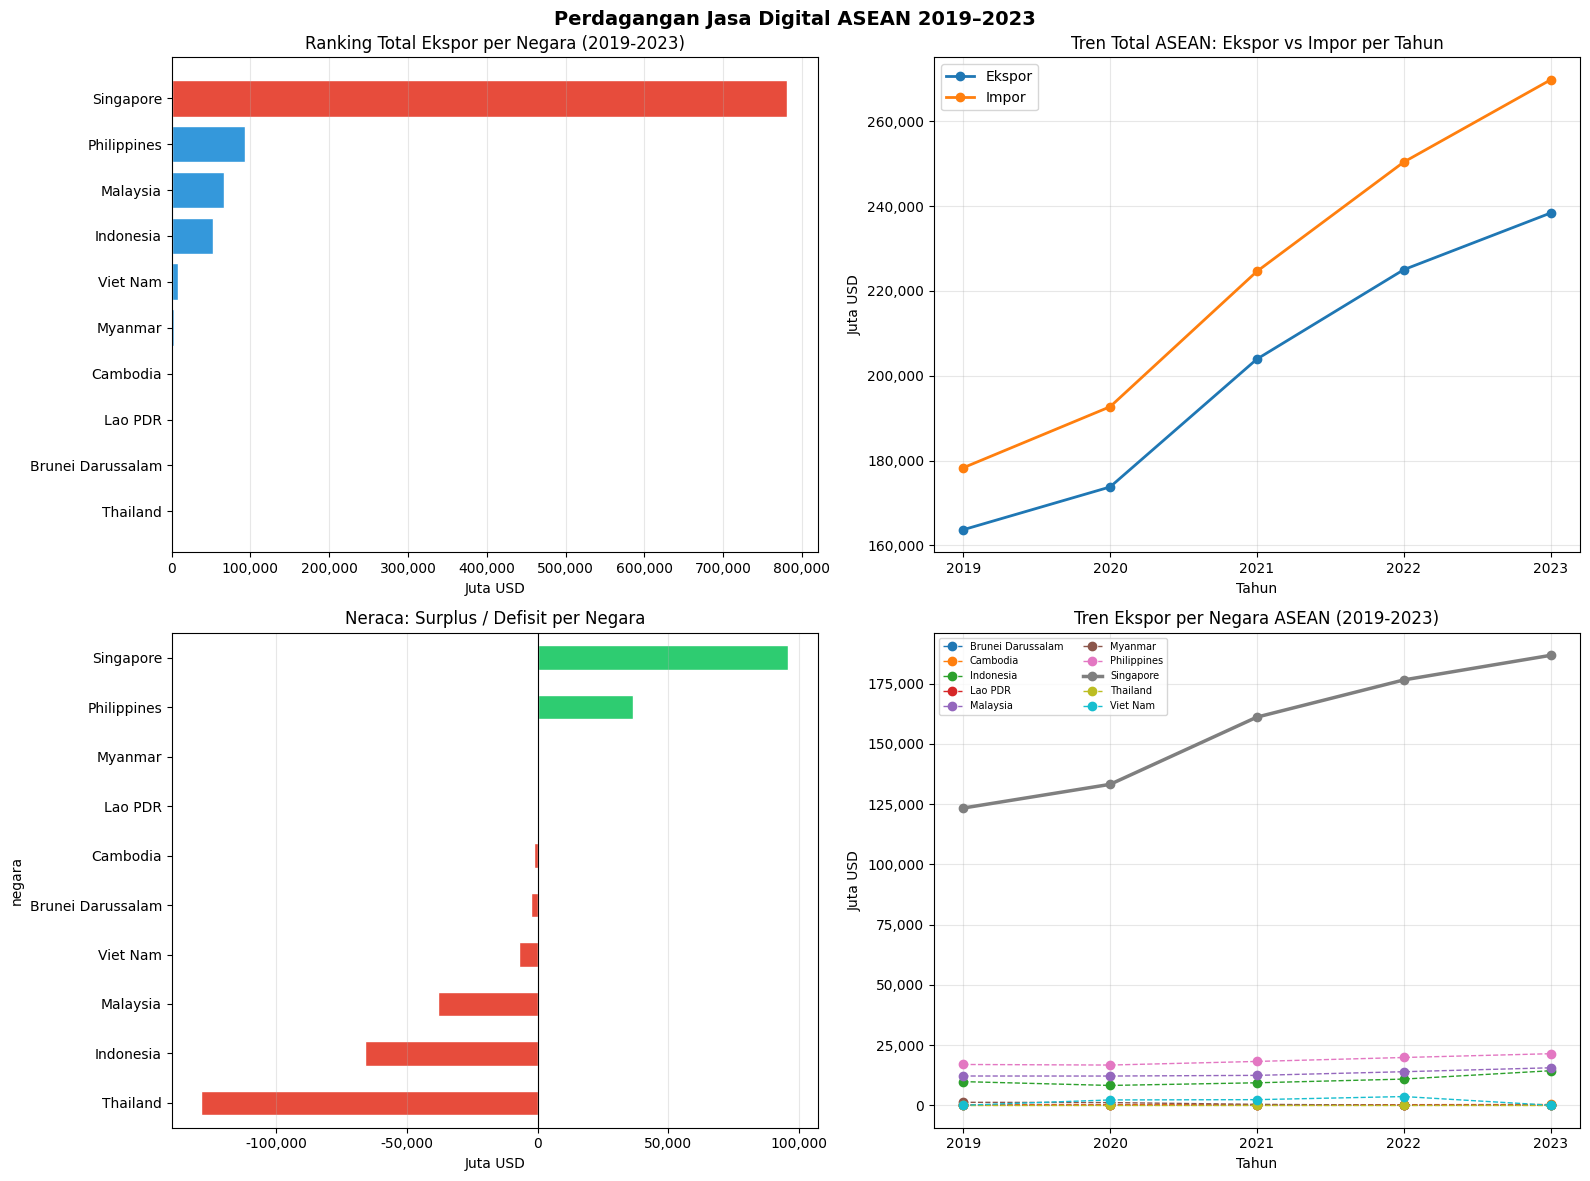

In [ ]:
#visualisasi
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Perdagangan Jasa Digital ASEAN 2019–2023', fontsize=14, fontweight='bold')

#ranking total ekspor per negara, singapura sebagai outlier dengan warna merah
ax = axes[0, 0]
exp_rank = (olap1[olap1['tipe'] == 'Ekspor'].sort_values('Total Nilai (Juta USD)', ascending=True))
colors_r = ['#e74c3c' if n == 'Singapore' else '#3498db' for n in exp_rank['negara']]
ax.barh(exp_rank['negara'], exp_rank['Total Nilai (Juta USD)'], color=colors_r, edgecolor='white')
ax.set_title('Ranking Total Ekspor per Negara (2019-2023)')
ax.set_xlabel('Juta USD')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.grid(axis='x', alpha=0.3)

#tren total ekspor dan impor kawasan per tahun
ax = axes[0, 1]
for tipe, grp in olap2.groupby('tipe'):
    ax.plot(grp['tahun'].astype(str), grp['Total Nilai (Juta USD)'], marker='o', linewidth=2, label=tipe)
ax.set_title('Tren Total ASEAN: Ekspor vs Impor per Tahun')
ax.set_ylabel('Juta USD'); ax.set_xlabel('Tahun')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.legend(); ax.grid(alpha=0.3)

#neracasurplus/defisit per negara, dengan warna merah untuk defisit dan hijau untuk surplus
ax = axes[1, 0]
neraca = pivot_sd['Neraca'].dropna().sort_values()
colors_n = ['#e74c3c' if v < 0 else '#2ecc71' for v in neraca]
neraca.plot(kind='barh', ax=ax, color=colors_n, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Neraca: Surplus / Defisit per Negara')
ax.set_xlabel('Juta USD')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.grid(axis='x', alpha=0.3)

#tren ekspor per negara, dengan singapura sebagai outlier yang diberi garis tebal dan warna merah
ax = axes[1, 1]
for neg, grp in olap3[olap3['tipe'] == 'Ekspor'].groupby('negara'):
    sub = grp.groupby('tahun')['Total Nilai (Juta USD)'].sum()
    lw  = 2.5 if neg == 'Singapore' else 1
    ls  = '-'  if neg == 'Singapore' else '--'
    ax.plot(sub.index.astype(str), sub.values, marker='o', label=neg, linewidth=lw, linestyle=ls)
ax.set_title('Tren Ekspor per Negara ASEAN (2019-2023)')
ax.set_ylabel('Juta USD'); ax.set_xlabel('Tahun')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Keempat panel visualisasi merangkum hasil analisis perdagangan jasa digital ASEAN 2019–2023 secara menyeluruh. Ranking total ekspor memperlihatkan dominasi Singapura yang sangat ekstrem dengan 781.109 juta USD, sementara Philippines, Malaysia, dan Indonesia berada jauh di bawahnya. Thailand bahkan tidak memiliki batang ekspor sama sekali karena data ekspor tidak tersedia di seluruh periode. Tren kawasan menunjukkan kedua kurva ekspor dan impor bergerak naik konsisten sepanjang 2019–2023, namun kurva impor selalu berada di atas kurva ekspor di setiap tahunnya. Gap antara keduanya bahkan semakin melebar terutama setelah 2020, mengindikasikan bahwa pertumbuhan permintaan jasa digital dari luar kawasan lebih cepat dari kemampuan ASEAN mengekspornya. Neraca surplus/defisit memperjelas bahwa hanya Singapura dan Philippines yang berwarna hijau, sementara delapan negara lainnya merah. Thailand mencatat defisit terdalam karena seluruh nilainya berasal dari impor, diikuti Indonesia dan Malaysia. Myanmar dan Lao PDR batangnya hampir tidak terlihat karena skala nilainya sangat kecil. Tren ekspor per negara semakin mempertegas ketimpangan kawasan, di mana garis Singapura jauh di atas semua negara lain yang terlihat hampir mendatar di bagian bawah grafik. Seluruh negara selain Singapura tumbuh sangat lambat dan sulit dibedakan satu sama lain karena perbedaan skala yang terlalu besar.

# Atoti

In [ ]:
import os
os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-21.0.11.10-hotspot" #reset javakhusus untuk sesi atoti agar tidak bentrok dengan java yang lain
os.environ["PATH"] = os.environ["JAVA_HOME"] + r"\bin;" + os.environ["PATH"]

In [53]:
session = tt.Session.start(tt.SessionConfig(port=9090))
print("Session Atoti berhasil dibuat")
print(f"Atoti UI: {session.url}")

Session Atoti berhasil dibuat
Atoti UI: http://localhost:9090


In [ ]:
df_cube = df_olap.copy()
df_cube['tahun'] = df_cube['time_period'].astype(str) #tahun ke string untuk hierarki waktu
df_cube['obs_value'] = pd.to_numeric(df_cube['obs_value'], errors='coerce')
df_cube = df_cube.dropna(subset=['obs_value']).reset_index(drop=True) #hapus baris tanpa nilai
df_cube.insert(0, 'id_cube', range(1, len(df_cube) + 1)) #primary key untuk cube

store = session.read_pandas(df_cube, table_name="fact_asean", keys=["id_cube"]) #load ke atoti stor
cube = session.create_cube(store, "ASEAN Digital Trade Cube") #buat cube
h = cube.hierarchies
m = cube.measures

h["Kawasan"] = [store["kawasan"]]
h["Negara"] = [store["kawasan"], store["ref_area_label"]] #hierarki negara dengan kawasan sebagai level atas
h["Tahun"] = [store["tahun"]]
h["Tipe"] = [store["tipe"]]
h["JenisPerdagangan"] = [store["indicator_label"]]

m["Nilai (Juta USD)"] = tt.agg.sum(store["obs_value"]) #agregasi jumlah
m["Jumlah Negara"] = tt.agg.count_distinct(store["ref_area_label"]) #hitung negara unik
print("Cube berhasil dibuat")

Cube berhasil dibuat


In [ ]:
print("CUBE QUERY 1: Total Ekspor & Impor per Negara")
q1 = cube.query(m["Nilai (Juta USD)"], levels=[h["Negara"]["ref_area_label"], h["Tipe"]["tipe"]]) #dimensi negara dan tipe perdagangan
print(q1.to_string())

CUBE QUERY 1: Total Ekspor & Impor per Negara
                                  Nilai (Juta USD)
kawasan ref_area_label    tipe                    
ASEAN   Brunei Darussalam Ekspor             82.00
                          Impor           2,652.00
        Cambodia          Ekspor          1,023.00
                          Impor           2,369.00
        Indonesia         Ekspor         52,500.00
                          Impor         118,296.00
        Lao PDR           Ekspor            194.00
                          Impor             254.00
        Malaysia          Ekspor         66,101.00
                          Impor         104,227.00
        Myanmar           Ekspor          2,674.00
                          Impor           2,658.00
        Philippines       Ekspor         92,990.00
                          Impor          56,534.00
        Singapore         Ekspor        781,109.00
                          Impor         685,168.00
        Thailand          Impor     

In [ ]:
print("CUBE QUERY 2: Tren Ekspor per Tahun per Negara")
q2 = cube.query(m["Nilai (Juta USD)"], levels=[h["Negara"]["ref_area_label"], h["Tahun"]["tahun"]], filter=h["Tipe"]["tipe"] == "Ekspor") #filter hanya ekspor
print(q2.to_string())

CUBE QUERY 2: Tren Ekspor per Tahun per Negara
                                 Nilai (Juta USD)
kawasan ref_area_label    tahun                  
ASEAN   Brunei Darussalam 2019               5.00
                          2020              11.00
                          2021              12.00
                          2022              15.00
                          2023              39.00
        Cambodia          2019             158.00
                          2020             173.00
                          2021             152.00
                          2022             222.00
                          2023             318.00
        Indonesia         2019           9,799.00
                          2020           8,213.00
                          2021           9,316.00
                          2022          10,853.00
                          2023          14,319.00
        Lao PDR           2019              62.00
                          2020              46.00
   

In [57]:
print("CUBE QUERY 3: Surplus / Defisit per Negara")
q3 = cube.query(m["Nilai (Juta USD)"], levels=[h["Negara"]["ref_area_label"], h["Tipe"]["tipe"]])
if isinstance(q3, pd.DataFrame):
    q3r = q3.reset_index()
    pivot_q3 = q3r.pivot_table(index="ref_area_label", columns="tipe", values="Nilai (Juta USD)", aggfunc="sum")
    if "Ekspor" in pivot_q3.columns and "Impor" in pivot_q3.columns:
        pivot_q3["Neraca"] = pivot_q3["Ekspor"].fillna(0) - pivot_q3["Impor"].fillna(0)
        pivot_q3["Status"] = pivot_q3["Neraca"].apply(lambda x: "Surplus" if x > 0 else ("Defisit" if x < 0 else "—"))
    print(pivot_q3.to_string())

CUBE QUERY 3: Surplus / Defisit per Negara
tipe                  Ekspor      Impor      Neraca   Status
ref_area_label                                              
Brunei Darussalam      82.00   2,652.00   -2,570.00  Defisit
Cambodia            1,023.00   2,369.00   -1,346.00  Defisit
Indonesia          52,500.00 118,296.00  -65,796.00  Defisit
Lao PDR               194.00     254.00      -60.00  Defisit
Malaysia           66,101.00 104,227.00  -38,126.00  Defisit
Myanmar             2,674.00   2,658.00       16.00  Surplus
Philippines        92,990.00  56,534.00   36,456.00  Surplus
Singapore         781,109.00 685,168.00   95,941.00  Surplus
Thailand                <NA> 128,665.00 -128,665.00  Defisit
Viet Nam            8,112.00  15,022.00   -6,910.00  Defisit


In [ ]:
print("CUBE QUERY 4: Total Kawasan ASEAN per Tahun")
q4 = cube.query(m["Nilai (Juta USD)"], levels=[h["Tahun"]["tahun"], h["Tipe"]["tipe"]]) #dimensi tahun dan tipe perdagangan untuk melihat tren kawasan
print(q4.to_string())

CUBE QUERY 4: Total Kawasan ASEAN per Tahun
              Nilai (Juta USD)
tahun tipe                    
2019  Ekspor        163,665.00
      Impor         178,286.00
2020  Ekspor        173,756.00
      Impor         192,684.00
2021  Ekspor        203,932.00
      Impor         224,628.00
2022  Ekspor        225,031.00
      Impor         250,422.00
2023  Ekspor        238,401.00
      Impor         269,825.00


Keempat query Atoti menghasilkan angka yang identik dengan hasil OLAP pandas sebelumnya, memvalidasi bahwa star schema dan pipeline ETL yang dibangun sudah benar. Cube Query 2 menunjukkan tren ekspor per negara per tahun di mana Singapura terus naik dari 122.895 (2019) hingga 186.790 juta USD (2023). Cube Query 4 mengkonfirmasi tren defisit kawasan yang konsisten di setiap tahun tanpa pengecualian.